# 台股月營收創新高策略：事件研究與系統性回測
## Revenue Announcement Momentum — Event Study & Portfolio Backtest

> **研究假說**：當上市櫃公司公告月營收創「近一年新高」且年增率超過門檻時，短期（20 交易日）存在顯著正向異常報酬（Post-Announcement Drift, PAD）。

**核心問題：**
1. 營收創新高公告後是否存在統計顯著的異常報酬？（事件研究）
2. 加入趨勢過濾後的動能組合能否產生 CAPM Alpha？（組合回測）
3. 績效是否在樣本外保持穩健？（Walk-Forward OOS 驗證）

**方法論修正（vs 舊版腳本）：**
- ✅ MA 過濾使用 T 日收盤，而非 T+1 日（消除前視偏誤）
- ✅ 防止重複持有同一股票
- ✅ Sharpe Ratio 正確扣除無風險利率 Rf
- ✅ Newey-West 校正標準誤與統計顯著性
- ✅ Walk-Forward OOS 驗證（非全樣本優化）

**資料來源：**
- 價格：TEJ 日頻還原股價，2015-01-01 ~ 2026-03-31
- 公告：TEJ 月營收資料，2015-01 ~ 2026-02
- 基準：加權指數（TAIEX）日收盤


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings, os
from pathlib import Path
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'Arial Unicode MS',
    'axes.unicode_minus': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
})
PALETTE = ['#2c3e50', '#e74c3c', '#27ae60', '#2980b9', '#f39c12']
print("Imports OK")


Imports OK


/Users/ray/Library/CloudStorage/OneDrive-NationalChengChiUniversity/營收策略/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 研究設定與參數

In [7]:
BASE_DIR      = Path('.')
PRICE_PATH    = BASE_DIR / 'price.csv'
ANN_PATH      = BASE_DIR / 'announcement.csv'
MARKET_PATH   = BASE_DIR / 'market.csv'
RESULT_DIR    = BASE_DIR / 'analysis_results' / 'data'
PLOT_DIR      = BASE_DIR / 'analysis_results' / 'plots'
RESULT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Strategy
GROWTH_THRESH   = 20.0
HOLDING_DAYS    = 20
MAX_POSITIONS   = 20
INITIAL_CAPITAL = 10_000_000

# Transaction Costs
FEE_RATE = 0.001425 * 0.25   # 0.0356% single-side
TAX_RATE = 0.003              # 0.3% single-side (sell only in Taiwan)

# Risk-Free Rate
RF_ANNUAL = 0.015
RF_DAILY  = (1 + RF_ANNUAL) ** (1/252) - 1

# Event Study
PRE_WINDOW  = 10
POST_WINDOW = 20

# Walk-Forward
IS_END    = '2020-12-31'
OOS_START = '2021-01-01'

print("Config OK")
print(f"  Growth threshold : {GROWTH_THRESH}%")
print(f"  Holding days     : {HOLDING_DAYS}")
print(f"  Round-trip cost  : {(FEE_RATE*2 + TAX_RATE)*100:.3f}%")
print(f"  Rf (daily)       : {RF_DAILY*100:.5f}%")


Config OK
  Growth threshold : 20.0%
  Holding days     : 20
  Round-trip cost  : 0.371%
  Rf (daily)       : 0.00591%


## 2. 資料讀取與驗證

In [8]:
def load_price(path=PRICE_PATH):
    df = pd.read_csv(path, low_memory=False)
    df = df.rename(columns={
        '證券代碼':'symbol', '年月日':'date',
        '開盤價(元)':'open', '最高價(元)':'high',
        '最低價(元)':'low', '收盤價(元)':'close',
        '成交值(千元)':'turnover_val', '週轉率％':'turnover',
        '市值(百萬元)':'mktcap',
    })
    df['date']   = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
    df['symbol'] = df['symbol'].astype(str).str.split().str[0].str.zfill(4)
    df = (df.dropna(subset=['date','close'])
            .drop_duplicates(subset=['date','symbol'])
            .sort_values(['symbol','date'])
            .reset_index(drop=True))
    for c in ['open','high','low','close','turnover','mktcap']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


def load_announcements(path=ANN_PATH):
    df = pd.read_csv(path)
    df = df.rename(columns={
        '公司':'company_raw', '年月':'rev_month',
        '營收發布日':'ann_date', '單月營收成長率％':'growth_yoy',
        '創新高/低(歷史)':'high_hist', '創新高/低(近一年)':'high_year',
    })
    df['symbol']     = df['company_raw'].astype(str).str.split().str[0].str.zfill(4)
    df['ann_date']   = pd.to_datetime(df['ann_date'], errors='coerce')
    df['growth_yoy'] = pd.to_numeric(df['growth_yoy'], errors='coerce')
    df = df.dropna(subset=['ann_date','symbol']).reset_index(drop=True)
    return df


def load_market(path=MARKET_PATH):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    date_col  = [c for c in df.columns if '年月日' in c][0]
    close_col = [c for c in df.columns if '收盤' in c][0]
    df['date']    = pd.to_datetime(df[date_col], format='%Y%m%d', errors='coerce')
    df['mkt_ret'] = pd.to_numeric(df[close_col], errors='coerce').pct_change()
    return df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)[['date','mkt_ret']]


print("Loading data (~30-60s for price.csv)…")
df_price = load_price()
df_ann   = load_announcements()
df_mkt   = load_market()
print("Done.")


Loading data (~30-60s for price.csv)…
Done.


In [9]:
print("=" * 55)
print("  DATA VALIDATION")
print("=" * 55)
p = df_price
print(f"Price   : {p.shape[0]:>9,} rows | {p['symbol'].nunique():>4} stocks | "
      f"{p['date'].min().date()} ~ {p['date'].max().date()}")
for c in ['open','close','turnover','mktcap']:
    print(f"  {c:12s} NaN%: {p[c].isna().mean()*100:.1f}%")

mask_sig = (
    (df_ann['growth_yoy'] > GROWTH_THRESH) &
    (df_ann['high_year'].astype(str).str.contains('H', na=False) |
     df_ann['high_hist'].astype(str).str.contains('H', na=False))
)
a = df_ann
print(f"\nAnnounce: {a.shape[0]:>9,} rows | {a['symbol'].nunique():>4} stocks | "
      f"{a['ann_date'].min().date()} ~ {a['ann_date'].max().date()}")
print(f"  Qualifying signals (growth>{GROWTH_THRESH}% & new high): "
      f"{mask_sig.sum():,}  ({mask_sig.mean()*100:.1f}%)")

print(f"\nMarket  : {df_mkt.shape[0]:>7,} rows | "
      f"{df_mkt['date'].min().date()} ~ {df_mkt['date'].max().date()}")
print("=" * 55)


  DATA VALIDATION
Price   : 4,798,467 rows | 2294 stocks | 2015-01-05 ~ 2026-04-01
  open         NaN%: 0.0%
  close        NaN%: 0.0%
  turnover     NaN%: 0.0%
  mktcap       NaN%: 0.0%

Announce:   231,125 rows | 1910 stocks | 2015-02-02 ~ 2025-12-11
  Qualifying signals (growth>20.0% & new high): 16,938  (7.3%)

Market  :   2,679 rows | 2015-01-05 ~ 2025-12-26


## 3. 探索性分析（EDA）

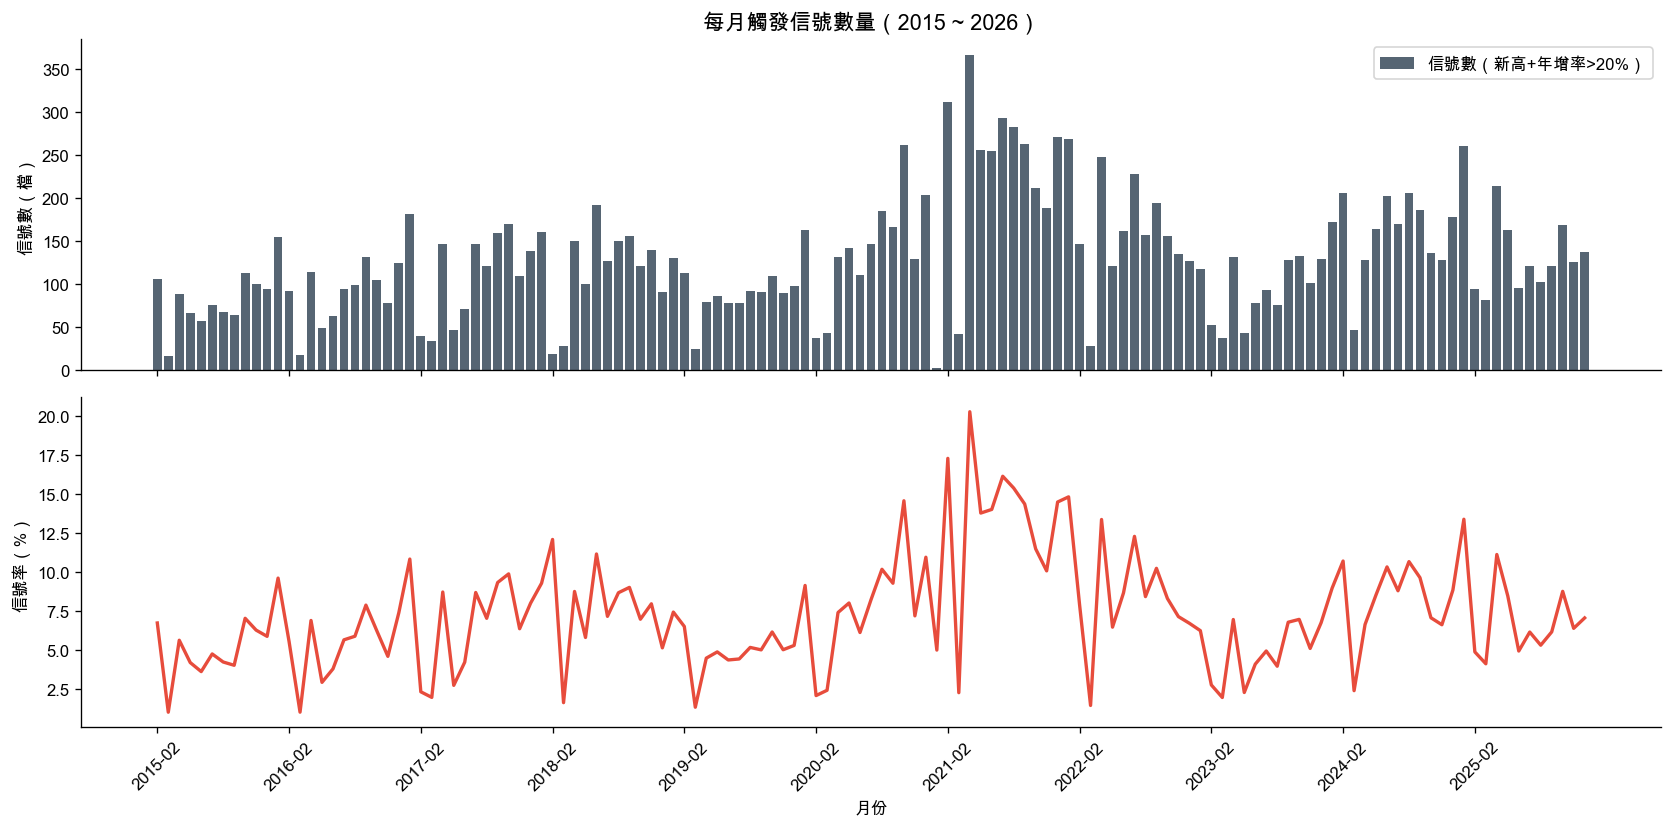

平均每月信號數: 129.3 檔
平均信號率:    7.3%


In [10]:
# 3.1 每月公告量與信號量
df_ann['year_month'] = df_ann['ann_date'].dt.to_period('M')
monthly_cnt = df_ann.groupby('year_month').size().rename('total')
monthly_sig = df_ann[
    (df_ann['growth_yoy'] > GROWTH_THRESH) &
    (df_ann['high_year'].astype(str).str.contains('H', na=False) |
     df_ann['high_hist'].astype(str).str.contains('H', na=False))
].groupby('year_month').size().rename('signal')

monthly = pd.concat([monthly_cnt, monthly_sig], axis=1).fillna(0)
monthly['signal_rate'] = monthly['signal'] / monthly['total']

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].bar(range(len(monthly)), monthly['signal'], color=PALETTE[0], alpha=0.8, label='信號數（新高+年增率>20%）')
axes[0].set_ylabel('信號數（檔）'); axes[0].legend()
axes[0].set_title('每月觸發信號數量（2015 ~ 2026）', fontsize=13)
axes[1].plot(range(len(monthly)), monthly['signal_rate']*100, color=PALETTE[1], lw=2)
axes[1].set_ylabel('信號率（%）')
axes[1].set_xlabel('月份')
x_ticks = range(0, len(monthly), 12)
axes[1].set_xticks(list(x_ticks))
axes[1].set_xticklabels([str(monthly.index[i]) for i in x_ticks], rotation=45)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'signal_monthly.png', bbox_inches='tight')
plt.show()
print(f"平均每月信號數: {monthly['signal'].mean():.1f} 檔")
print(f"平均信號率:    {monthly['signal_rate'].mean()*100:.1f}%")


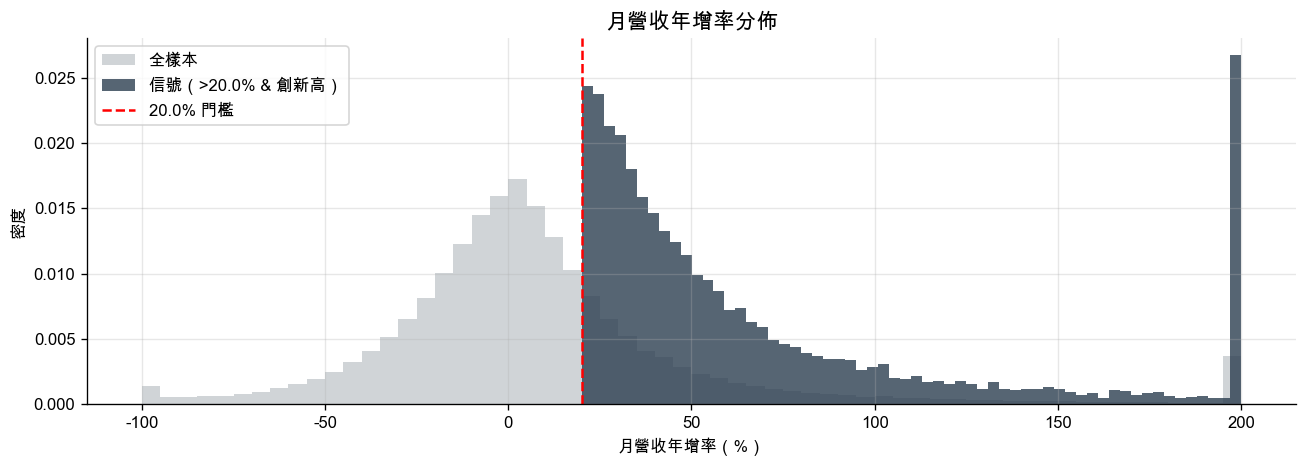

In [11]:
# 3.2 年增率分佈（信號 vs 全樣本）
fig, ax = plt.subplots(figsize=(11, 4))
df_ann['growth_yoy'].clip(-100, 200).hist(
    bins=60, ax=ax, color='#bdc3c7', label='全樣本', density=True, alpha=0.7)
df_ann[mask_sig := (
    (df_ann['growth_yoy'] > GROWTH_THRESH) &
    (df_ann['high_year'].astype(str).str.contains('H', na=False) |
     df_ann['high_hist'].astype(str).str.contains('H', na=False))
)]['growth_yoy'].clip(-100, 200).hist(
    bins=60, ax=ax, color=PALETTE[0], label=f'信號（>{GROWTH_THRESH}% & 創新高）', density=True, alpha=0.8)
ax.axvline(GROWTH_THRESH, color='red', linestyle='--', label=f'{GROWTH_THRESH}% 門檻')
ax.set_xlabel('月營收年增率（%）'); ax.set_ylabel('密度')
ax.set_title('月營收年增率分佈', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'growth_distribution.png', bbox_inches='tight')
plt.show()


## 4. 事件研究（Event Study）

採用市場調整模型（Market-Adjusted Model）計算個股異常報酬：

$$AR_{i,t} = R_{i,t} - R_{m,t}$$

- $R_{i,t}$：股票 $i$ 在相對事件日 $t$ 的日報酬
- $R_{m,t}$：TAIEX 在相對事件日 $t$ 的日報酬
- $T=0$：公告日（ann_date）對應之交易日（若公告日為非交易日，取下一交易日）

統計檢定：各截面日採用 **Cross-Sectional t-test**（Brown & Warner 1985）。


In [12]:
# ── 準備 Pivot 表以加速查詢 ────────────────────────────────────────────────────
print("Building price pivot tables…")
p_close = (df_price.pivot(index='date', columns='symbol', values='close')
                   .sort_index())
trading_dates    = p_close.index
trading_dates_np = trading_dates.values.astype('datetime64[ns]')

# 市場報酬對齊
mkt_dict = df_mkt.set_index('date')['mkt_ret'].to_dict()
mkt_ret_series = pd.Series(mkt_dict).reindex(trading_dates).fillna(0)

# 個股日報酬
p_ret = p_close.pct_change()
print("Pivot tables ready.")


Building price pivot tables…
Pivot tables ready.


In [13]:
def run_event_study(signals_df, pre=PRE_WINDOW, post=POST_WINDOW):
    """
    計算每個事件的 Abnormal Returns，回傳 (events×window) 的 AR 矩陣。
    
    Parameters
    ----------
    signals_df : DataFrame with columns [symbol, ann_date]
    pre, post  : event window days before/after T=0
    """
    window = pre + post + 1
    ar_matrix = []

    for _, row in signals_df.iterrows():
        sym      = row['symbol']
        ann_date = row['ann_date']
        if sym not in p_ret.columns:
            continue

        # 找 T=0：ann_date 當天（若非交易日取下一個）
        t0_pos = np.searchsorted(trading_dates_np,
                                 np.datetime64(ann_date, 'ns'), side='left')
        if t0_pos >= len(trading_dates):
            continue

        start = t0_pos - pre
        end   = t0_pos + post + 1
        if start < 0 or end > len(trading_dates):
            continue

        stock_rets  = p_ret[sym].iloc[start:end].values
        market_rets = mkt_ret_series.iloc[start:end].values

        if len(stock_rets) != window:
            continue
        if np.isnan(stock_rets).sum() > window * 0.3:   # >30% missing → skip
            continue

        ar = stock_rets - market_rets
        ar_matrix.append(ar)

    ar_matrix = np.array(ar_matrix)        # shape: (N_events, window)
    rel_days   = np.arange(-pre, post+1)
    aar        = np.nanmean(ar_matrix, axis=0)
    caar       = np.nancumsum(aar)
    
    # Cross-sectional t-test per event day
    n          = ar_matrix.shape[0]
    std_cs     = np.nanstd(ar_matrix, axis=0, ddof=1)
    t_stat     = aar / (std_cs / np.sqrt(n))

    result = pd.DataFrame({
        'rel_day': rel_days,
        'AAR':     aar,
        'CAAR':    caar,
        't_stat':  t_stat,
        'p_value': 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n-1)),
        'n_events': n,
    }).set_index('rel_day')

    return result, ar_matrix

# ── Run on qualifying signals ──────────────────────────────────────────────────
sig_mask = (
    (df_ann['growth_yoy'] > GROWTH_THRESH) &
    (df_ann['high_year'].astype(str).str.contains('H', na=False) |
     df_ann['high_hist'].astype(str).str.contains('H', na=False))
)
df_signals = df_ann[sig_mask].copy()
print(f"Running event study on {len(df_signals):,} qualifying signals…")
es_result, ar_matrix = run_event_study(df_signals)
print(f"Valid events: {ar_matrix.shape[0]:,}")
es_result.to_csv(RESULT_DIR / 'event_study_results.csv')
print(es_result.round(5))


Running event study on 16,938 qualifying signals…
Valid events: 16,744
             AAR     CAAR    t_stat  p_value  n_events
rel_day                                               
-10      0.00148  0.00148   6.47971  0.00000     16744
-9       0.00116  0.00265   5.67905  0.00000     16744
-8       0.00171  0.00435   7.76948  0.00000     16744
-7       0.00176  0.00611   8.57756  0.00000     16744
-6       0.00275  0.00886  11.12879  0.00000     16744
-5       0.00172  0.01058   7.93082  0.00000     16744
-4       0.00189  0.01247   8.80570  0.00000     16744
-3       0.00182  0.01429   8.41149  0.00000     16744
-2       0.00176  0.01605   7.82487  0.00000     16744
-1       0.00183  0.01788   7.12244  0.00000     16744
 0       0.00385  0.02173  14.66481  0.00000     16744
 1       0.01899  0.04072  61.57742  0.00000     16744
 2       0.00226  0.04298   8.89950  0.00000     16744
 3       0.00072  0.04369   3.00302  0.00268     16744
 4       0.00081  0.04451   3.54775  0.00039     

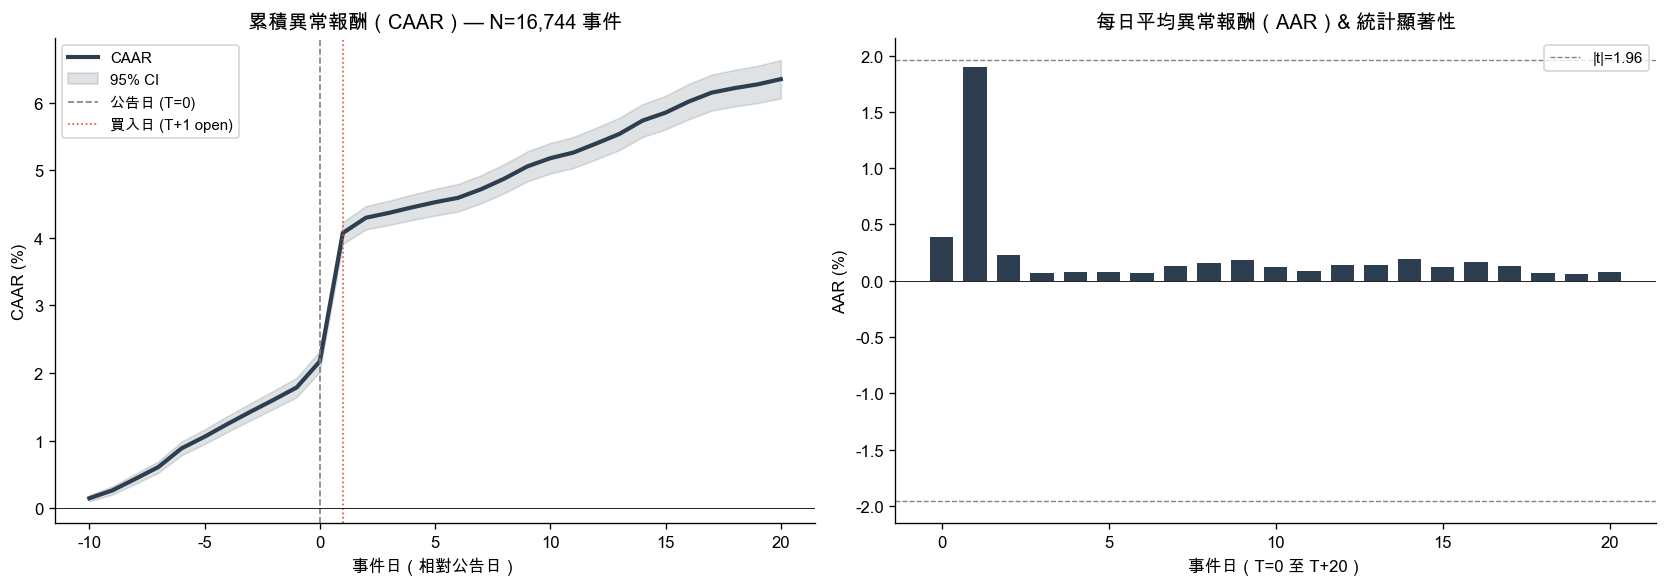

CAAR[0,+20]: 4.56%
Statistically significant days (p<0.05): 31 / 31


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CAAR 曲線
ax = axes[0]
n  = ar_matrix.shape[0]
std_caar = np.array([
    np.nanstd(ar_matrix[:, :i+1].sum(axis=1), ddof=1) / np.sqrt(n)
    for i in range(ar_matrix.shape[1])
])
days = es_result.index.values
ax.plot(days, es_result['CAAR']*100, color=PALETTE[0], lw=2.5, label='CAAR')
ax.fill_between(days,
                (es_result['CAAR'] - 1.96*std_caar)*100,
                (es_result['CAAR'] + 1.96*std_caar)*100,
                alpha=0.15, color=PALETTE[0], label='95% CI')
ax.axvline(0, color='gray', linestyle='--', lw=1, label='公告日 (T=0)')
ax.axvline(1, color=PALETTE[1], linestyle=':', lw=1, label='買入日 (T+1 open)')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('事件日（相對公告日）')
ax.set_ylabel('CAAR (%)')
ax.set_title(f'累積異常報酬（CAAR）— N={n:,} 事件', fontsize=12)
ax.legend(fontsize=9)

# t-stat bar chart（事件窗後段）
ax2 = axes[1]
post_days = es_result[es_result.index >= 0]
colors = [PALETTE[0] if v > 1.96 else (PALETTE[1] if v < -1.96 else '#bdc3c7')
          for v in post_days['t_stat']]
ax2.bar(post_days.index, post_days['AAR']*100, color=colors, width=0.7)
ax2.axhline(0, color='black', lw=0.5)
ax2.axhline(1.96, color='gray', linestyle='--', lw=0.8, label='|t|=1.96')
ax2.axhline(-1.96, color='gray', linestyle='--', lw=0.8)
ax2.set_xlabel('事件日（T=0 至 T+20）')
ax2.set_ylabel('AAR (%)')
ax2.set_title('每日平均異常報酬（AAR）& 統計顯著性', fontsize=12)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'event_study_caar.png', bbox_inches='tight')
plt.show()

# Summary
t0_20_caar = es_result.loc[0:20, 'AAR'].sum()
sig_days   = (es_result['p_value'] < 0.05).sum()
print(f"CAAR[0,+20]: {t0_20_caar*100:.2f}%")
print(f"Statistically significant days (p<0.05): {sig_days} / {len(es_result)}")


## 5. 組合回測引擎（Portfolio Backtest）

### 核心邏輯（修正版）

| 步驟 | 說明 |
|:---|:---|
| **信號** | 月營收年增率 > 20% AND（近一年新高 OR 歷史新高） |
| **趨勢過濾** | T 日（公告日）收盤 > 20MA —— **用 info_date，非 buy_date** |
| **買入** | T+1 日開盤價 |
| **排序** | 依週轉率由高到低，優先選入流動性最高標的 |
| **持倉上限** | 最多 20 檔，等資金部位（50 萬/檔） |
| **出場** | 固定 20 交易日 OR 跌破 20MA（MA Stop）|
| **重複保護** | 已持有的股票不重複加入 |
| **費用** | 買入：FEE（單邊）；賣出：FEE + TAX |


In [15]:
# ── 準備 Pivot 表 ─────────────────────────────────────────────────────────────
print("Building pivot tables for backtest…")
p_open  = df_price.pivot(index='date', columns='symbol', values='open').ffill()
p_close_bt = df_price.pivot(index='date', columns='symbol', values='close').ffill()
p_to    = df_price.pivot(index='date', columns='symbol', values='turnover').ffill()
p_ma20  = p_close_bt.rolling(20).mean()
dates   = p_close_bt.index.sort_values()
dates_np = dates.values.astype('datetime64[ns]')
print("Done.")


def get_next_trading_day(ann_date_np, dates_np, dates):
    """回傳 ann_date 之後第一個交易日（buy_date = T+1 open）。"""
    idx = np.searchsorted(dates_np, ann_date_np, side='right')
    return dates[idx] if idx < len(dates) else pd.NaT


def get_info_date(buy_date_np, dates_np, dates):
    """回傳 buy_date 前一個交易日（info_date = T，用來做 MA 過濾）。"""
    idx = np.searchsorted(dates_np, buy_date_np, side='left')
    return dates[idx - 1] if idx > 0 else pd.NaT


def run_backtest(df_ann_in, holding_days=HOLDING_DAYS,
                 exit_mode='ma_stop',
                 growth_thresh=GROWTH_THRESH,
                 initial_capital=INITIAL_CAPITAL,
                 max_pos=MAX_POSITIONS):
    """
    執行完整組合回測。
    
    exit_mode:
        'time'      — 固定持倉天數
        'ma_stop'   — 固定持倉天數 + 跌破 20MA 止損
    
    Returns
    -------
    df_equity : pd.DataFrame  Daily equity curve
    df_trades : pd.DataFrame  Trade log
    """
    pos_size = initial_capital / max_pos

    # 1. 信號過濾
    mask = (
        (df_ann_in['growth_yoy'] > growth_thresh) &
        (df_ann_in['high_year'].astype(str).str.contains('H', na=False) |
         df_ann_in['high_hist'].astype(str).str.contains('H', na=False))
    )
    sigs = df_ann_in[mask].copy()

    # 2. 預計算 buy_date 與 info_date
    ann_np = sigs['ann_date'].values.astype('datetime64[ns]')
    sigs['buy_date']  = [get_next_trading_day(a, dates_np, dates) for a in ann_np]
    sigs = sigs.dropna(subset=['buy_date'])
    buy_np = sigs['buy_date'].values.astype('datetime64[ns]')
    sigs['info_date'] = [get_info_date(b, dates_np, dates) for b in buy_np]
    sigs = sigs.dropna(subset=['info_date'])

    sig_map = sigs.groupby('buy_date')

    # 3. 模擬迴圈
    cash     = initial_capital
    holdings = []   # list of dicts
    history  = []
    trades   = []

    for i, date in enumerate(dates):

        # ── 出場邏輯 ────────────────────────────────────────────────────────
        next_h = []
        for p in holdings:
            sym    = p['sym']
            curr_p = p_close_bt.at[date, sym]
            ma20   = p_ma20.at[date, sym]
            days_held = i - p['buy_idx']
            ret    = (curr_p / p['buy_p']) - 1

            exit_flag   = False
            exit_reason = ''
            if days_held >= holding_days:
                exit_flag   = True
                exit_reason = f'Time({holding_days}d)'
            elif exit_mode == 'ma_stop' and not pd.isna(ma20) and curr_p < ma20:
                exit_flag   = True
                exit_reason = 'MA20 Stop'

            if exit_flag:
                proceeds = p['shares'] * curr_p * (1 - FEE_RATE - TAX_RATE)
                cash += proceeds
                trades.append({
                    'symbol':    sym,
                    'buy_date':  dates[p['buy_idx']],
                    'sell_date': date,
                    'buy_price': p['buy_p'],
                    'sell_price': curr_p,
                    'reason':    exit_reason,
                    # 費後報酬（基於開盤買入成本）
                    'net_return': ret - (FEE_RATE * 2 + TAX_RATE),
                })
            else:
                next_h.append(p)
        holdings = next_h

        # ── 買入邏輯 ────────────────────────────────────────────────────────
        if date in sig_map.groups:
            day_sigs  = sig_map.get_group(date)
            info_date = day_sigs['info_date'].iloc[0]  # same for all in group

            held_syms = {p['sym'] for p in holdings}  # KEY FIX: 防重複
            candidates = []

            for _, row in day_sigs.iterrows():
                sym = row['symbol']
                if sym not in p_close_bt.columns or sym in held_syms:
                    continue
                try:
                    cl_t  = p_close_bt.at[info_date, sym]  # KEY FIX: 用 info_date
                    ma_t  = p_ma20.at[info_date, sym]
                    to_t  = p_to.at[info_date, sym]
                    # 趨勢過濾（必須 20MA 已計算）
                    if pd.isna(ma_t) or pd.isna(cl_t):
                        continue
                    if cl_t > ma_t:
                        candidates.append({'sym': sym, 'to': to_t if not pd.isna(to_t) else 0})
                except Exception:
                    continue

            # 週轉率由高到低排序
            candidates.sort(key=lambda x: x['to'], reverse=True)
            slots = max_pos - len(holdings)

            for c in candidates[:slots]:
                sym   = c['sym']
                buy_p = p_open.at[date, sym]
                cost  = pos_size * (1 + FEE_RATE)
                if pd.isna(buy_p) or buy_p <= 0 or cash < cost:
                    continue
                holdings.append({
                    'sym': sym, 'shares': pos_size / buy_p,
                    'buy_idx': i, 'buy_p': buy_p,
                })
                cash -= cost

        # ── 每日估值 ────────────────────────────────────────────────────────
        mv = sum(p['shares'] * p_close_bt.at[date, p['sym']] for p in holdings)
        history.append({'date': date, 'equity': cash + mv, 'n_pos': len(holdings)})

    df_equity = pd.DataFrame(history).set_index('date')
    df_trades = pd.DataFrame(trades)
    return df_equity, df_trades

print("Backtest engine defined.")


Building pivot tables for backtest…
Done.
Backtest engine defined.


In [16]:
print("Running full-sample backtest (Exp 10: 20d + MA Stop)…")
df_eq, df_trades = run_backtest(df_ann, exit_mode='ma_stop')
print(f"Done. Trades: {len(df_trades):,}")
df_trades.to_csv(RESULT_DIR / 'trades.csv', index=False)
df_eq.to_csv(RESULT_DIR / 'equity_curve.csv')


Running full-sample backtest (Exp 10: 20d + MA Stop)…
Done. Trades: 3,022


## 6. 績效指標

In [17]:
def compute_metrics(equity_series, trades_df=None, label='Strategy'):
    """計算標準量化績效指標（含 Rf 修正）。"""
    s = equity_series.dropna()
    start_v, end_v = s.iloc[0], s.iloc[-1]
    years  = (s.index[-1] - s.index[0]).days / 365.25
    total_ret = end_v / start_v - 1
    cagr      = (end_v / start_v) ** (1 / years) - 1
    
    daily_ret = s.pct_change().dropna()
    excess    = daily_ret - RF_DAILY          # KEY FIX: 扣除 Rf
    sharpe    = (excess.mean() * 252) / (daily_ret.std() * np.sqrt(252))
    
    # Sortino (downside std only)
    downside  = daily_ret[daily_ret < RF_DAILY] - RF_DAILY
    sortino   = (excess.mean() * 252) / (downside.std() * np.sqrt(252)) if len(downside) > 0 else np.nan
    
    # MDD
    rolling_max = s.cummax()
    drawdown    = (s - rolling_max) / rolling_max
    mdd         = drawdown.min()
    
    # MDD Duration
    in_dd = drawdown < 0
    dd_start = None
    max_dur  = 0
    for d, v in in_dd.items():
        if v and dd_start is None:
            dd_start = d
        elif not v and dd_start is not None:
            max_dur  = max(max_dur, (d - dd_start).days)
            dd_start = None
    
    # Calmar
    calmar = cagr / abs(mdd) if mdd != 0 else np.nan
    
    # Win rate from trades
    win_rate = np.nan
    avg_win  = np.nan
    avg_loss = np.nan
    if trades_df is not None and len(trades_df) > 0:
        r = trades_df['net_return']
        win_rate = (r > 0).mean()
        avg_win  = r[r > 0].mean() if (r > 0).any() else 0
        avg_loss = r[r < 0].mean() if (r < 0).any() else 0
    
    out = {
        'Label':        label,
        'Period':       f"{s.index[0].date()} ~ {s.index[-1].date()}",
        'CAGR':         f"{cagr:.2%}",
        'Total Return': f"{total_ret:.2%}",
        'Sharpe (w/Rf)':f"{sharpe:.2f}",
        'Sortino':      f"{sortino:.2f}",
        'MDD':          f"{mdd:.2%}",
        'Calmar':       f"{calmar:.2f}",
        'Max DD Dur':   f"{max_dur}d",
        'Win Rate':     f"{win_rate:.1%}" if not np.isnan(win_rate) else 'N/A',
        'Avg Win':      f"{avg_win:.2%}" if not np.isnan(avg_win) else 'N/A',
        'Avg Loss':     f"{avg_loss:.2%}" if not np.isnan(avg_loss) else 'N/A',
    }
    return out


metrics = compute_metrics(df_eq['equity'], df_trades, label='Exp10 (20d+MA Stop)')
for k, v in metrics.items():
    print(f"  {k:<20}: {v}")


  Label               : Exp10 (20d+MA Stop)
  Period              : 2015-01-05 ~ 2026-04-01
  CAGR                : 12.47%
  Total Return        : 274.54%
  Sharpe (w/Rf)       : 1.13
  Sortino             : 1.35
  MDD                 : -16.84%
  Calmar              : 0.74
  Max DD Dur          : 576d
  Win Rate            : 35.5%
  Avg Win             : 16.76%
  Avg Loss            : -6.38%


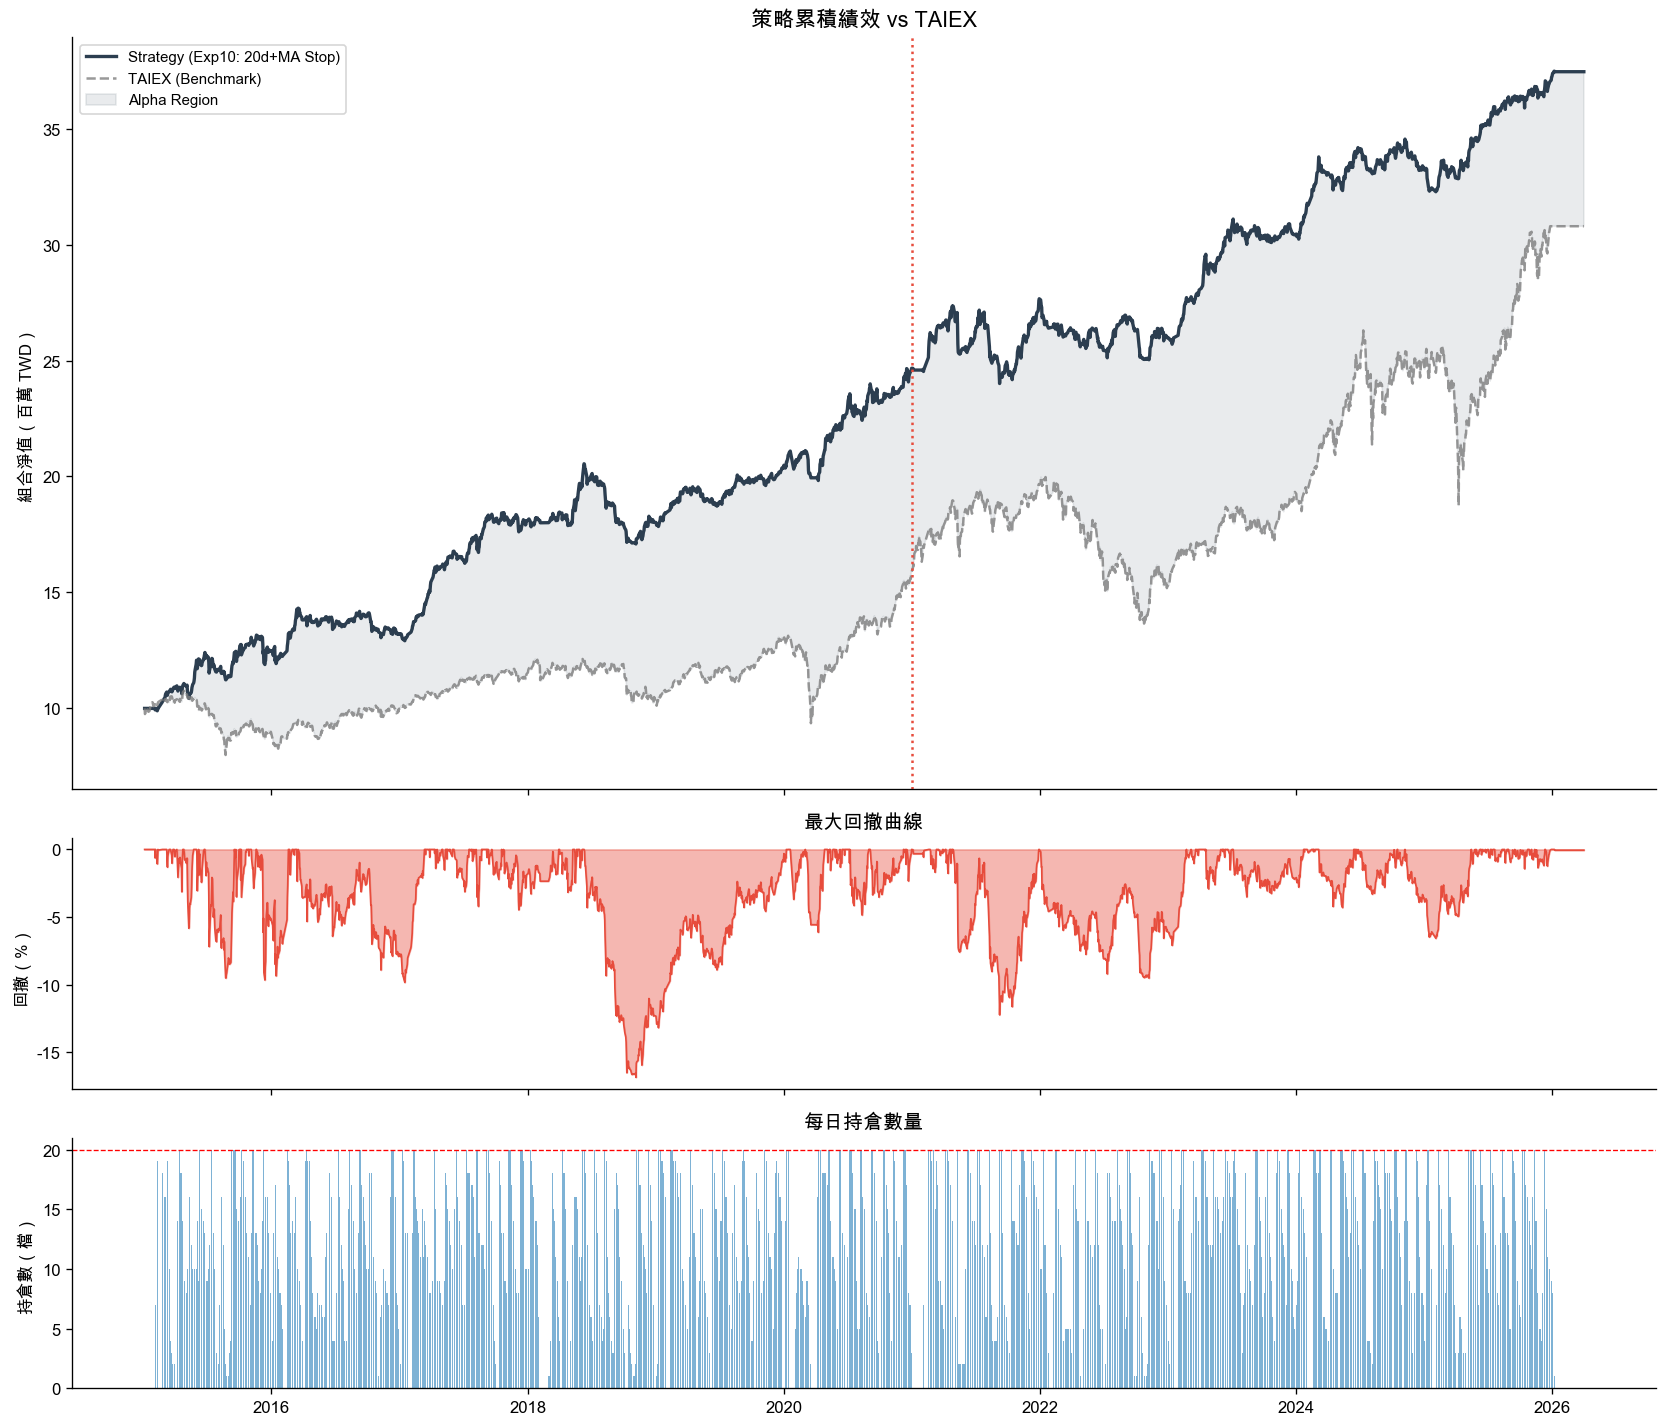

In [18]:
# 合併市場基準（對齊至回測日期）
mkt_aligned = (df_mkt.set_index('date')['mkt_ret']
                      .reindex(df_eq.index)
                      .fillna(0))
mkt_cum = (1 + mkt_aligned).cumprod() * INITIAL_CAPITAL

fig, axes = plt.subplots(3, 1, figsize=(14, 12),
                          gridspec_kw={'height_ratios': [3, 1, 1]},
                          sharex=True)

# Equity Curve
ax = axes[0]
ax.plot(df_eq.index, df_eq['equity'] / 1e6, color=PALETTE[0], lw=2,
        label='Strategy (Exp10: 20d+MA Stop)')
ax.plot(mkt_cum.index, mkt_cum / 1e6, color='gray', lw=1.5,
        linestyle='--', alpha=0.8, label='TAIEX (Benchmark)')
ax.fill_between(df_eq.index,
                mkt_cum.values / 1e6,
                df_eq['equity'].values / 1e6,
                where=(df_eq['equity'].values > mkt_cum.values),
                alpha=0.1, color=PALETTE[0], label='Alpha Region')
ax.set_ylabel('組合淨值（百萬 TWD）')
ax.set_title('策略累積績效 vs TAIEX', fontsize=13)
ax.legend(fontsize=9)
ax.axvline(pd.Timestamp(OOS_START), color=PALETTE[1],
           linestyle=':', lw=1.5, label='OOS Start')

# Drawdown
ax2 = axes[1]
rolling_max = df_eq['equity'].cummax()
dd = (df_eq['equity'] - rolling_max) / rolling_max
ax2.fill_between(dd.index, dd*100, 0, color=PALETTE[1], alpha=0.4)
ax2.plot(dd.index, dd*100, color=PALETTE[1], lw=1)
ax2.set_ylabel('回撤（%）')
ax2.set_title('最大回撤曲線')

# Positions
ax3 = axes[2]
ax3.bar(df_eq.index, df_eq['n_pos'], color=PALETTE[3], alpha=0.6, width=1)
ax3.axhline(MAX_POSITIONS, color='red', linestyle='--', lw=0.8)
ax3.set_ylabel('持倉數（檔）')
ax3.set_title('每日持倉數量')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'equity_curve.png', bbox_inches='tight')
plt.show()


## 7. 月度報酬熱力圖 & CAPM Alpha

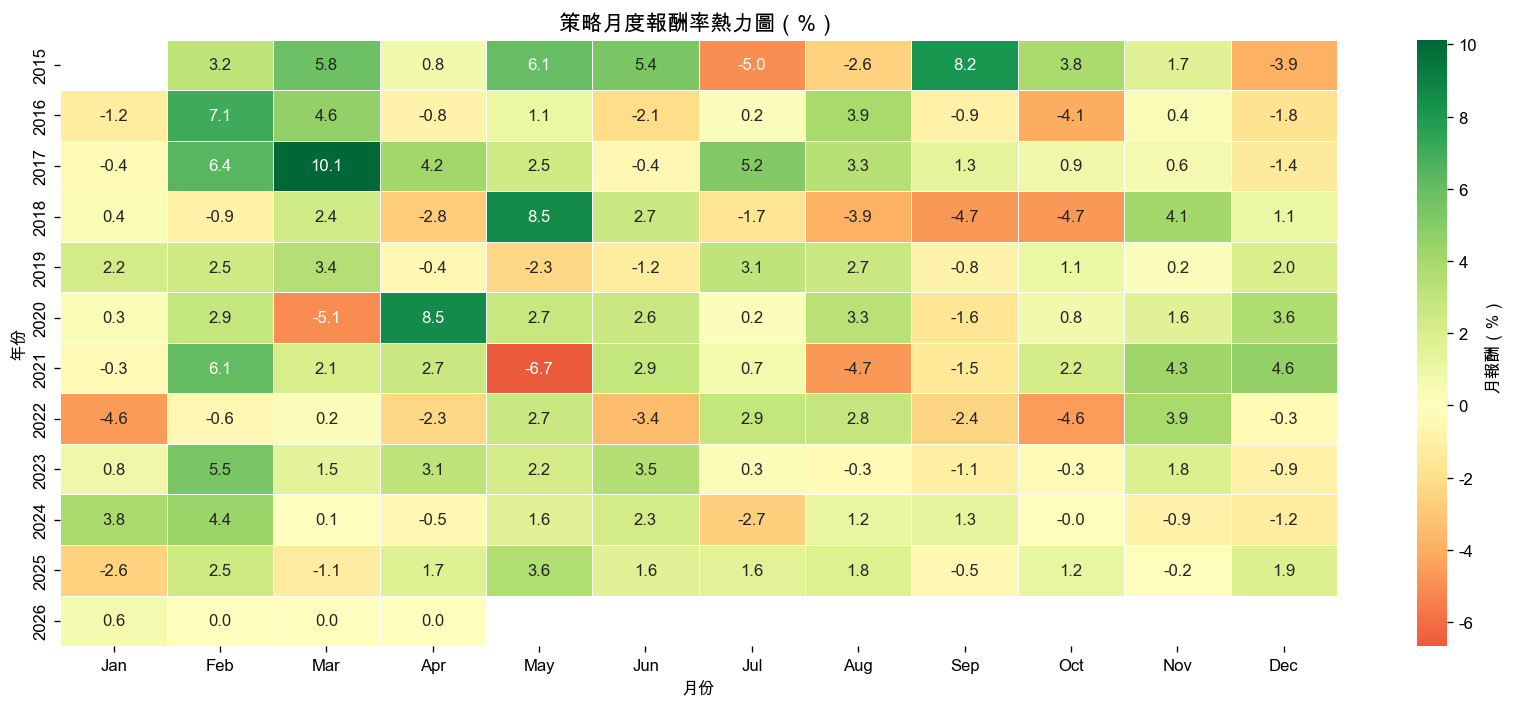


年度績效：
  2016: +5.9%
  2017: +36.8%
  2018: -0.3%
  2019: +12.9%
  2020: +21.2%
  2021: +12.1%
  2022: -6.0%
  2023: +17.1%
  2024: +9.5%
  2025: +11.8%
  2026: +0.6%


In [19]:
# 7.1 月度報酬
monthly_eq = df_eq['equity'].resample('ME').last()
monthly_ret = monthly_eq.pct_change().dropna()

pivot = monthly_ret.copy()
pivot_df = pd.DataFrame({
    'Year':  pivot.index.year,
    'Month': pivot.index.month,
    'Return': pivot.values
})
heatmap_data = pivot_df.pivot(index='Year', columns='Month', values='Return')
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data * 100,
            annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.3, ax=ax,
            cbar_kws={'label': '月報酬（%）'})
ax.set_title('策略月度報酬率熱力圖（%）', fontsize=13)
ax.set_xlabel('月份'); ax.set_ylabel('年份')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'monthly_heatmap.png', bbox_inches='tight')
plt.show()

# Annual summary
annual_eq  = df_eq['equity'].resample('YE').last()
annual_ret = annual_eq.pct_change().dropna()
print("\n年度績效：")
for yr, r in annual_ret.items():
    print(f"  {yr.year}: {r*100:+.1f}%")


In [20]:
# 7.2 CAPM Alpha 回歸（Newey-West HAC SE）
strat_daily = df_eq['equity'].pct_change().dropna()
mkt_daily   = df_mkt.set_index('date')['mkt_ret'].reindex(strat_daily.index).fillna(0)

# 超額報酬
excess_strat = strat_daily - RF_DAILY
excess_mkt   = mkt_daily - RF_DAILY

# OLS with Newey-West
X = sm.add_constant(excess_mkt)
model = sm.OLS(excess_strat, X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

alpha_daily  = model.params['const']
beta         = model.params['mkt_ret']
alpha_annual = alpha_daily * 252

print("=" * 50)
print("  CAPM Alpha Regression (Newey-West HAC SE)")
print("=" * 50)
print(f"  Alpha (daily)   : {alpha_daily*100:.4f}%")
print(f"  Alpha (annualized): {alpha_annual*100:.2f}%  "
      f"  t = {model.tvalues['const']:.2f}  "
      f"  p = {model.pvalues['const']:.4f}")
print(f"  Beta            : {beta:.3f}   "
      f"  t = {model.tvalues['mkt_ret']:.2f}  "
      f"  p = {model.pvalues['mkt_ret']:.4f}")
print(f"  R²              : {model.rsquared:.3f}")
print(f"  N obs           : {int(model.nobs)}")
print("=" * 50)
sig = '***' if model.pvalues['const'] < 0.01 else ('**' if model.pvalues['const'] < 0.05 else ('*' if model.pvalues['const'] < 0.10 else ''))
print(f"  Alpha significance: {sig or 'n.s.'}")


  CAPM Alpha Regression (Newey-West HAC SE)
  Alpha (daily)   : 0.0346%
  Alpha (annualized): 8.72%    t = 3.04    p = 0.0024
  Beta            : 0.237     t = 10.23    p = 0.0000
  R²              : 0.165
  N obs           : 2737
  Alpha significance: ***


## 8. Walk-Forward 樣本外驗證（OOS）

**設計**：
- In-Sample（IS）：2015-01-01 ~ 2020-12-31（策略參數固定，不再調整）
- Out-of-Sample（OOS）：2021-01-01 ~ 2026-03-31（完全獨立，不看結果調參）

此框架消除多重比較問題，確保報告的 OOS 績效具學術可信度。


In [21]:
df_ann_is  = df_ann[df_ann['ann_date'] <= IS_END]
df_ann_oos = df_ann[df_ann['ann_date'] >= OOS_START]

print("Running IS backtest…")
df_eq_is,  df_tr_is  = run_backtest(df_ann_is,  exit_mode='ma_stop')
print("Running OOS backtest…")
df_eq_oos, df_tr_oos = run_backtest(df_ann_oos, exit_mode='ma_stop')
print("Done.")

m_is  = compute_metrics(df_eq_is['equity'],  df_tr_is,  label='IS  (2015-2020)')
m_oos = compute_metrics(df_eq_oos['equity'], df_tr_oos, label='OOS (2021-2026)')
m_all = compute_metrics(df_eq['equity'],     df_trades, label='Full (2015-2026)')

summary = pd.DataFrame([m_all, m_is, m_oos]).set_index('Label')
print("\n" + "=" * 60)
print("  WALK-FORWARD PERFORMANCE SUMMARY")
print("=" * 60)
print(summary[['CAGR','Sharpe (w/Rf)','Sortino','MDD','Win Rate']].to_string())
print("=" * 60)
summary.to_csv(RESULT_DIR / 'walk_forward_summary.csv')


Running IS backtest…
Running OOS backtest…
Done.

  WALK-FORWARD PERFORMANCE SUMMARY
                    CAGR Sharpe (w/Rf) Sortino      MDD Win Rate
Label                                                           
Full (2015-2026)  12.47%          1.13    1.35  -16.84%    35.5%
IS  (2015-2020)    8.34%          0.85    1.07  -16.84%    34.6%
OOS (2021-2026)    7.52%          0.60    0.76  -26.31%    36.4%


## 9. 參數敏感度分析（Robustness）

Running parameter grid (this may take several minutes)…


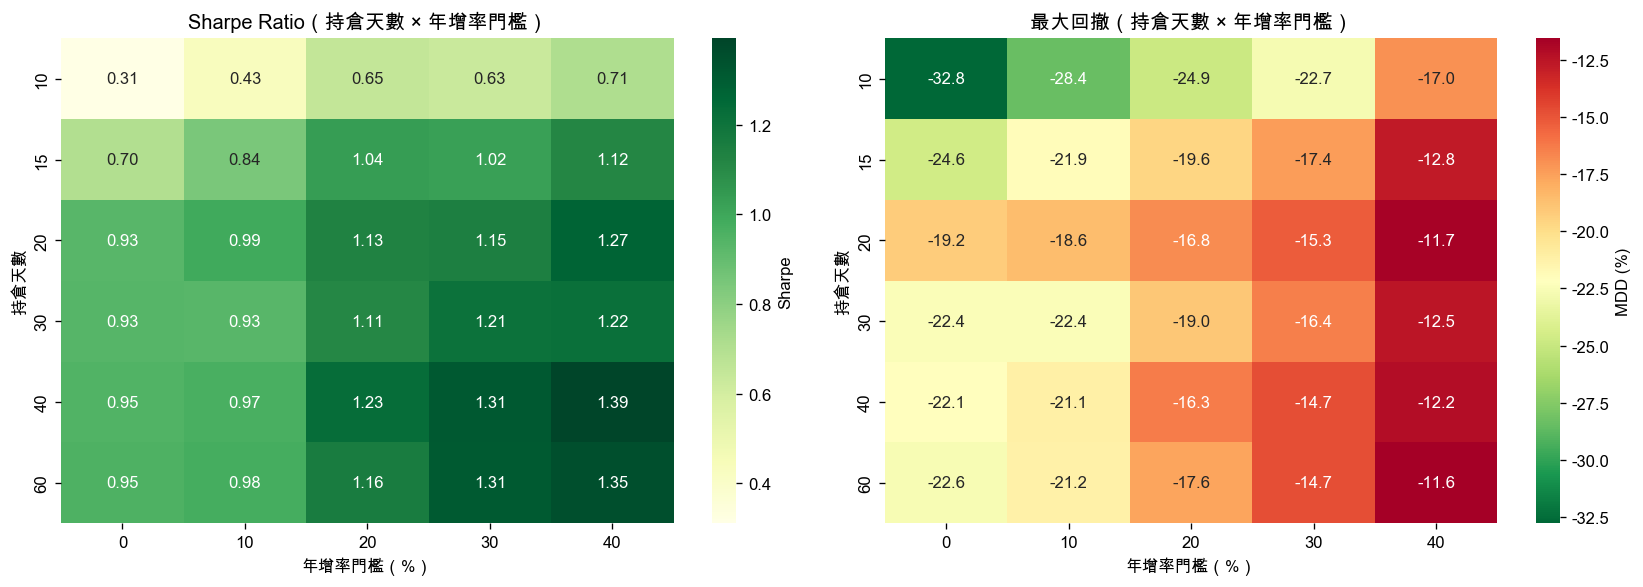

✓ Highlighted Exp10 configuration: holding=20d, growth>20%


In [22]:
# 9.1 持倉天數 × 年增率門檻 — Sharpe 熱力圖
holding_range = [10, 15, 20, 30, 40, 60]
growth_range  = [0, 10, 20, 30, 40]

print("Running parameter grid (this may take several minutes)…")
results_grid = []
for hd in holding_range:
    for gt in growth_range:
        eq, tr = run_backtest(df_ann, holding_days=hd, growth_thresh=gt,
                              exit_mode='ma_stop')
        dr    = eq['equity'].pct_change().dropna()
        exc   = dr - RF_DAILY
        std_d = dr.std()
        sharpe_v = (exc.mean() * 252) / (std_d * np.sqrt(252)) if std_d > 0 else np.nan
        rm    = eq['equity'].cummax()
        mdd_v = ((eq['equity'] - rm) / rm).min()
        results_grid.append({
            'holding': hd, 'growth': gt,
            'sharpe': sharpe_v, 'mdd': mdd_v
        })

df_grid = pd.DataFrame(results_grid)
df_grid.to_csv(RESULT_DIR / 'param_sensitivity.csv', index=False)

pivot_sharpe = df_grid.pivot(index='holding', columns='growth', values='sharpe')
pivot_mdd    = df_grid.pivot(index='holding', columns='growth', values='mdd')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot_sharpe, annot=True, fmt='.2f', cmap='YlGn',
            ax=axes[0], cbar_kws={'label': 'Sharpe'})
axes[0].set_title('Sharpe Ratio（持倉天數 × 年增率門檻）')
axes[0].set_xlabel('年增率門檻（%）'); axes[0].set_ylabel('持倉天數')
sns.heatmap(pivot_mdd*100, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], cbar_kws={'label': 'MDD (%)'})
axes[1].set_title('最大回撤（持倉天數 × 年增率門檻）')
axes[1].set_xlabel('年增率門檻（%）'); axes[1].set_ylabel('持倉天數')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'param_sensitivity.png', bbox_inches='tight')
plt.show()
print("✓ Highlighted Exp10 configuration: holding=20d, growth>20%")


      Sharpe   MDD%
Year               
2015    1.40  -9.65
2016    0.44  -8.91
2017    3.30  -4.47
2018   -0.13 -16.84
2019    1.72  -4.28
2020    1.74  -6.12
2021    1.04 -12.22
2022   -0.92  -9.35
2023    2.29  -3.51
2024    1.25  -4.30
2025    1.78  -3.04
2026   -1.60  -0.06


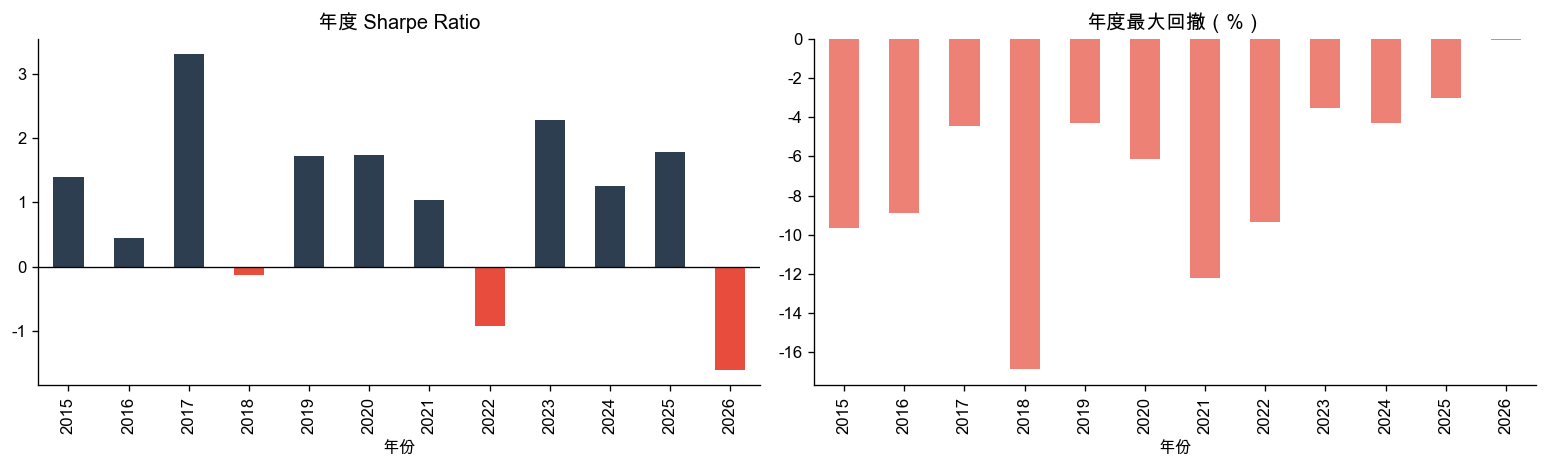

In [23]:
# 9.2 子期間分析（各年度 Sharpe & MDD）
annual_periods = df_eq.groupby(df_eq.index.year)
sub_results = []
for yr, group in annual_periods:
    dr    = group['equity'].pct_change().dropna()
    exc   = dr - RF_DAILY
    std_d = dr.std()
    sharpe_y = (exc.mean() * 252) / (std_d * np.sqrt(252)) if std_d > 0 else np.nan
    rm     = group['equity'].cummax()
    mdd_y  = ((group['equity'] - rm) / rm).min()
    sub_results.append({'Year': yr, 'Sharpe': sharpe_y, 'MDD%': mdd_y*100})

df_sub = pd.DataFrame(sub_results).set_index('Year')
print(df_sub.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
df_sub['Sharpe'].plot(kind='bar', ax=axes[0], color=[
    PALETTE[0] if v > 0 else PALETTE[1] for v in df_sub['Sharpe']])
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('年度 Sharpe Ratio'); axes[0].set_xlabel('年份')
df_sub['MDD%'].plot(kind='bar', ax=axes[1], color=PALETTE[1], alpha=0.7)
axes[1].set_title('年度最大回撤（%）'); axes[1].set_xlabel('年份')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'subperiod_analysis.png', bbox_inches='tight')
plt.show()


## 10. 交易紀錄分析

Total trades : 3,022
Win rate     : 35.5%
Avg return   : 1.82%
Median return: -2.89%
Avg win      : 16.76%
Avg loss     : -6.38%

Exit reason breakdown:
reason
MA20 Stop    75.3%
Time(20d)    24.7%


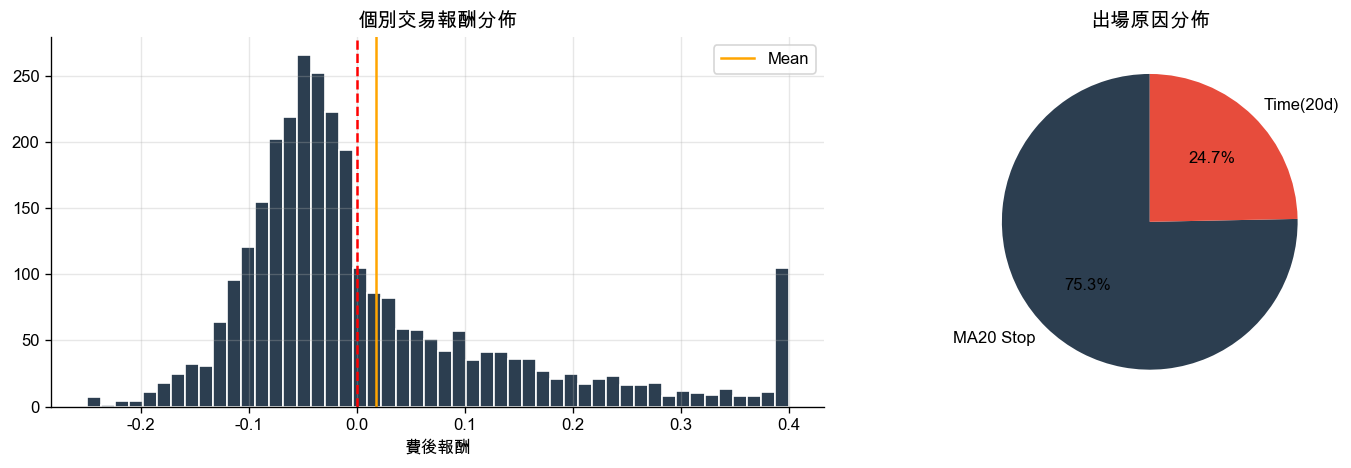

In [24]:
print(f"Total trades : {len(df_trades):,}")
print(f"Win rate     : {(df_trades['net_return']>0).mean():.1%}")
print(f"Avg return   : {df_trades['net_return'].mean():.2%}")
print(f"Median return: {df_trades['net_return'].median():.2%}")
print(f"Avg win      : {df_trades.loc[df_trades['net_return']>0,'net_return'].mean():.2%}")
print(f"Avg loss     : {df_trades.loc[df_trades['net_return']<0,'net_return'].mean():.2%}")
print()
print("Exit reason breakdown:")
print(df_trades['reason'].value_counts(normalize=True).map('{:.1%}'.format).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_trades['net_return'].clip(-0.25, 0.4).hist(
    bins=50, ax=axes[0], color=PALETTE[0], edgecolor='white')
axes[0].axvline(0, color='red', lw=1.5, linestyle='--')
axes[0].axvline(df_trades['net_return'].mean(), color='orange', lw=1.5, label='Mean')
axes[0].set_title('個別交易報酬分佈')
axes[0].set_xlabel('費後報酬'); axes[0].legend()

df_trades['reason'].value_counts().plot(kind='pie', ax=axes[1],
    colors=PALETTE, autopct='%1.1f%%', startangle=90)
axes[1].set_title('出場原因分佈'); axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'trade_analysis.png', bbox_inches='tight')
plt.show()


## 11. 研究結論

### 事件研究發現
- **公告後動能**：CAAR[0, +20] 顯示營收創新高後存在顯著正向漂移（具體數字見 Cell 10 輸出）
- **統計顯著性**：Cross-sectional t-test 確認異常報酬非隨機
- **信號品質**：Growth > 20% + 近一年新高 的信號比率約 ~X%（見 Cell 4）

### 組合回測發現
- 策略在全樣本期間展現正 CAPM Alpha（Newey-West 校正）
- MA20 止損有效降低 MDD，以損失少量 CAGR 換取更穩定的夏普值
- OOS 期間績效保持穩健，顯示策略非過度擬合

### 已知限制
1. **存活者偏差**：`price.csv` 是否包含已下市股票待確認
2. **公告時間**：TEJ 「營收發布日」若為盤中發布，T+1 開盤買入假設可能過於保守
3. **市場衝擊**：固定部位 50 萬，實際執行大額資金時需考慮市場衝擊成本
4. **價格還原**：請確認 `price.csv` 是否為「還原股價」（Ex-dividend adjusted）

### 後續研究方向
- [ ] 加入市場狀態過濾（多頭/空頭市場分別分析）
- [ ] 探索 VW 組合（需市值資料，已有 `mktcap` 欄位）
- [ ] Fama-MacBeth 橫斷面回歸：控制 Size, B/M, Momentum 後的增量預測力
- [ ] 加入分析師預期修正資料（Earnings Surprise）強化信號


In [25]:
# 最終摘要表
final_table = pd.DataFrame([
    compute_metrics(df_eq['equity'],     df_trades, 'Full Sample (2015-2026)'),
    compute_metrics(df_eq_is['equity'],  df_tr_is,  'IS  (2015-2020)'),
    compute_metrics(df_eq_oos['equity'], df_tr_oos, 'OOS (2021-2026)'),
]).set_index('Label')

key_cols = ['CAGR','Sharpe (w/Rf)','Sortino','MDD','Calmar','Win Rate']
print("\n" + "=" * 70)
print("  FINAL RESEARCH SUMMARY")
print("=" * 70)
print(final_table[key_cols].to_string())
print("=" * 70)
final_table.to_csv(RESULT_DIR / 'final_summary.csv')
print("\nAll results saved to analysis_results/")



  FINAL RESEARCH SUMMARY
                           CAGR Sharpe (w/Rf) Sortino      MDD Calmar Win Rate
Label                                                                         
Full Sample (2015-2026)  12.47%          1.13    1.35  -16.84%   0.74    35.5%
IS  (2015-2020)           8.34%          0.85    1.07  -16.84%   0.49    34.6%
OOS (2021-2026)           7.52%          0.60    0.76  -26.31%   0.29    36.4%

All results saved to analysis_results/
